# DRG group E

## Notes 
### Codes For Cost Bases
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 4 = Outplaced pupils"
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 3 = Total pupils transported"

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [1]:
import os
from os import path, mkdir
import glob
import re
import warnings
from datetime import datetime
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"
    
def dollar_k1(x, pos):
    return f"${int(x/1000):,.1f}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_k1_formatter = ticker.FuncFormatter(dollar_k1)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Author': 'Joel Danke',
'Description': "DRG group E",
'Creation Time': rundate,
'Software': software}

## Read data

In [5]:
# all have the "grouping" vars JSG, % w/Bachelors, etc.
totalstaff = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/totalstaff.parquet')
function_exp = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/expenditures.parquet')
accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability.parquet')


## Filter to "Peer Group"
Dropping Southington - it is just too large!

In [6]:
# peer selection
PEERVAR = "finprojE"
peer_condition = f"{PEERVAR} > 0"

#make directory if needed
try:
    mkdir(f"./charts/peer_districts/{PEERVAR}")
except FileExistsError:
    pass

### Staffing
This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [7]:
# ignore elementary districts
totalstaff['SpecialEd Share Of Ed'] = (totalstaff['SpecialEd'] / (totalstaff['Educational'] + totalstaff['SpecialEd']))
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                       (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')]\
            .query(peer_condition).copy()

peerstaff = peerstaff[~peerstaff['District'].str.startswith('Southington')]
peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

### Expenditures

In [8]:
# filter to remove non-essential schools, functions
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services'])) &
                                (function_exp['High Grade'] == 12)]\
                    .query(peer_condition).copy()

# not sure this is used
peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE Growth'].median().reset_index().rename(columns={'PPE Growth': 'Median PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])

peer_expenditures = peer_expenditures[~peer_expenditures['District'].str.startswith('Southington')]
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

In [9]:
function_exp.groupby('Function').agg({'District': 'nunique', 'Year': 'nunique'})

,District,Year
Function,,
Administration and Support Services,190,5
Central and other support services,199,8
Enterprise operations,199,8
Food services,199,8
Instruction,199,13
Minor school construction,199,8
Operation and maintenance of plant,199,13
Student transportation services,199,13
Support services - general administration,199,13


In [10]:
function_exp.groupby('Function').agg({'Year': 'max'})

,Year
Function,
Administration and Support Services,2016-17
Central and other support services,2024-25
Enterprise operations,2024-25
Food services,2024-25
Instruction,2024-25
Minor school construction,2024-25
Operation and maintenance of plant,2024-25
Student transportation services,2024-25
Support services - general administration,2024-25


### Accountability

**No Covid Years**  

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

In [11]:
# remove nonessential schools
peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                     (accountability['High Grade'] == 12)]\
                     .query(peer_condition).copy()

peer_accountability = peer_accountability[~peer_accountability['District'].str.startswith('Southington')]
peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')

## Combine accountability, expenditures, staffing

Select columns to avoid duplicates.

In [12]:
# Avoid duplicating clustering variables when getting staff data
peerdrop = [x for x in peerstaff.columns if ((x in peer_expenditures.columns) & (x not in ['Year', 'District']))]

# For accountability index select only necessary variables
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
           'Physical Fitness', 'Arts Access', 'AccountabilityIndex']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

In [13]:
# add "total" expenditures, accountability index
peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total']\
                .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])
peer_combined['Expenditures Per Student'] = peer_combined['Expenditures'] / peer_combined['Enrollment']

# same, but for "instructional" expenditures
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction']\
                   .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                   .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])

peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

In [14]:
# help w/plotting styles
peerstaff[PEERVAR] = peerstaff[PEERVAR].where(~peerstaff['District'].str.startswith('Region'), 3)
peer_expenditures[PEERVAR] = peer_expenditures[PEERVAR].where(~peer_expenditures['District'].str.startswith('Region'), 3)
peer_accountability[PEERVAR] = peer_accountability[PEERVAR].where(~peer_accountability['District'].str.startswith('Region'), 3)
peer_combined[PEERVAR] = peer_combined[PEERVAR].where(~peer_combined['District'].str.startswith('Region'), 3)
peer_instruction[PEERVAR] = peer_instruction[PEERVAR].where(~peer_instruction['District'].str.startswith('Region'), 3)

### Peer Overview

In [15]:
peer_combined.query('Year == "2024-25"')[['Year', 'District', 'Enrollment', 'Expenditures', 'AccountabilityIndex', 'Payroll Per Student', 'Expenditures Per Student']]\
    .sort_values('Expenditures Per Student')\
    .style.format({"AccountabilityIndex": "{:,.1f}"} |
                  { x: "${:,.0f}" for x in ["Payroll Per Student", "Expenditures Per Student", "Expenditures"]} |
                  {'Enrollment': "{:,.0f}"} )\
    .hide(axis="index")

Year,District,Enrollment,Expenditures,AccountabilityIndex,Payroll Per Student,Expenditures Per Student
2024-25,Wolcott School District,"2,100","$43,335,531",78.3,"$15,370","$20,636"
2024-25,Granby School District,"1,709","$39,033,285",82.8,"$17,085","$22,840"
2024-25,East Hampton School District,"1,676","$40,740,556",77.2,"$19,827","$24,308"
2024-25,Thomaston School District,777,"$19,656,075",77.7,"$17,404","$25,297"
2024-25,East Windsor School District,"1,035","$31,272,689",71.6,"$23,920","$30,215"


In [16]:
# Largest YoY growth
peer_expenditures[peer_expenditures['Function'] == 'Instruction'].groupby('District')['Real PPE Growth'].max().sort_values()

District
Thomaston School District       1.038985
East Windsor School District    1.084057
Wolcott School District         1.084518
Granby School District          1.147319
East Hampton School District    1.167050
Name: Real PPE Growth, dtype: float64

### Year vs 2ago changes
Attempt to comparing instructional and accountability growth. No COVID years is problematic

In [17]:
# calculate % change from prior year
changecols = ['Pupils', 'PPE', 'Instruction $', 'Instruction $ Per Student',
              'Real Instruction $', 'Real PPE', 'Real Instruction $ Per Student',
              'Teachers', 'Educational', 'Student: Teachers Ratio', 'AccountabilityIndex']

# % change vs two years ago
changes = peer_instruction.groupby('District')[changecols].diff(2)/peer_instruction.groupby('District')[changecols].shift(2)

changes = changes.join(peer_instruction[['District', 'Year', 'Town', 'Type', 'Granby']].rename(columns={'Pupils': 'Students'}), how='inner')

changes.head(10).tail(5)

,Pupils,PPE,Instruction $,Instruction $ Per Student,Real Instruction $,Real PPE,Real Instruction $ Per Student,Teachers,Educational,Student: Teachers Ratio,AccountabilityIndex,District,Year,Town,Type,Granby
5,0.045230,0.044993,0.092241,0.044993,0.055787,0.010116,0.010116,0.028571,0.029762,-0.040104,0.045056,East Hampton School District,2017-18,East Hampton,Town,Other
6,0.045916,0.041106,0.088896,0.041106,0.050409,0.004307,0.004307,-0.055646,-0.046310,0.054974,0.085840,East Hampton School District,2018-19,East Hampton,Town,Other
7,-0.036511,0.033998,-0.003766,0.033998,-0.037060,-0.000558,-0.000558,-0.073529,-0.057803,0.063772,NaN,East Hampton School District,2019-20,East Hampton,Town,Other
8,-0.040327,0.097035,0.052770,0.097035,0.022909,0.065919,0.065919,-0.024263,-0.016692,0.000191,NaN,East Hampton School District,2020-21,East Hampton,Town,Other
9,-0.036842,0.137834,0.095961,0.137834,0.018944,0.057875,0.057875,0.012346,0.026840,-0.042226,NaN,East Hampton School District,2021-22,East Hampton,Town,Other


## Color Scheme

In [18]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in peer_combined['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

## Special Education Staffing

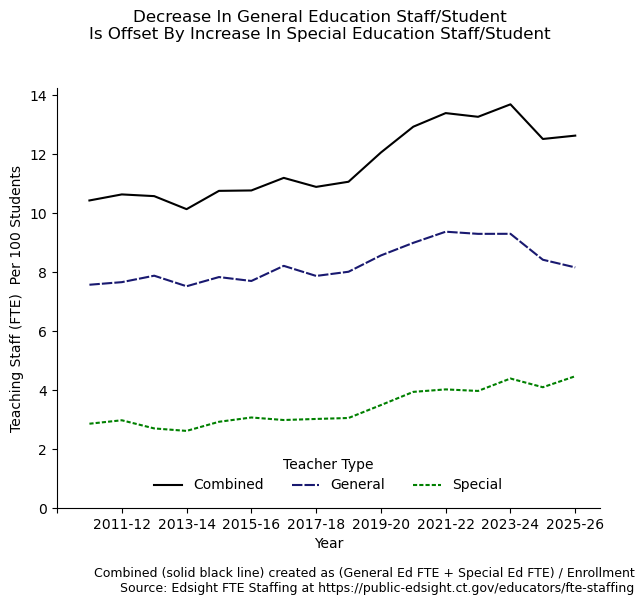

In [19]:
tmpdf = peerstaff.query('Town == "Granby"')

tmpdf = pd.melt(tmpdf, id_vars=['Year'], value_vars=['Instructional Per 100 Student', 'Educational Per 100 Student','SpecialEd Per 100 Student'],
        var_name='type', value_name='value', ignore_index=True)

tmpdf['Teacher Type'] = tmpdf['type'].where(tmpdf['type'].str.startswith('Instructional'), 'General')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['type'].str.startswith('Special'), 'Special')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['Teacher Type'].str.startswith('Instructional'), 'Combined')


fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Decrease In General Education Staff/Student\nIs Offset By Increase In Special Education Staff/Student')

ax = sns.lineplot(data=tmpdf, x='Year', y='value',
                  hue='Teacher Type', palette=['black', 'midnightblue', 'green'],
                  style='Teacher Type', dashes=[(None, None), (5, 1), (2, 1)],
                  ax=ax)

# every other year
current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)

ax.set_ylim(bottom=0)
ax.set_ylabel("Teaching Staff (FTE)  Per 100 Students")

sns.move_legend(ax, loc="upper center",
                bbox_to_anchor=(0.5, 0.15), ncols=3,
                frameon=False, )

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Combined (solid black line) created as (General Ed FTE + Special Ed FTE) / Enrollment\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_share_of_staff_granby.png", dpi=200, metadata=png_metadata)

plt.show()

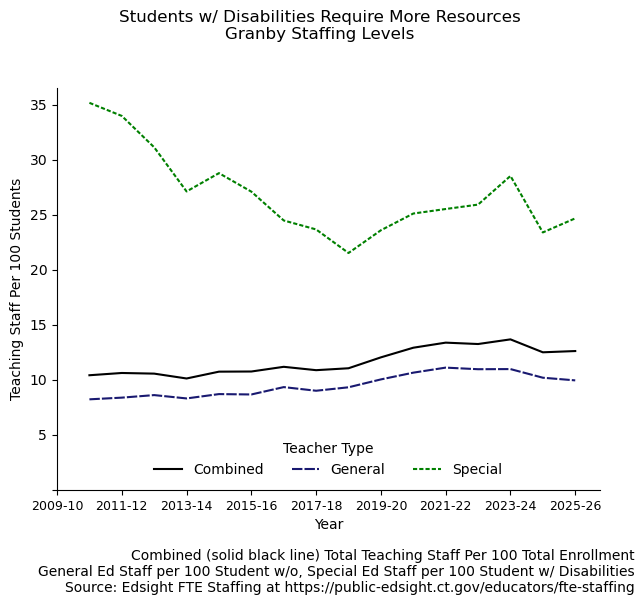

In [20]:
tmpdf = peerstaff.query('Town == "Granby"')
tmpdf = pd.melt(tmpdf, id_vars=['Year'], value_vars=['Instructional Per 100 Student',
                                                     'Educational Per 100 Student w/o Disabilities',
                                                     'SpecialEd Per 100 Student w/ Disabilities'],
        var_name='type', value_name='value', ignore_index=True)

tmpdf['Teacher Type'] = tmpdf['type'].where(tmpdf['type'].str.startswith('Instructional'), 'General')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['type'].str.startswith('Special'), 'Special')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['Teacher Type'].str.startswith('Instructional'), 'Combined')


fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Students w/ Disabilities Require More Resources\nGranby Staffing Levels')

ax = sns.lineplot(data=tmpdf, x='Year', y='value',
                  hue='Teacher Type', palette=['black', 'midnightblue', 'green'],
                  style='Teacher Type', dashes=[(None, None), (5, 1), (2, 1)],
                  ax=ax)

# every other year
current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
labels = ax.yaxis.get_ticklabels()
labels[0].set_visible(False)
plt.xticks(fontsize=9)

ax.set_ylim(bottom=0)
ax.set_ylabel("Teaching Staff Per 100 Students")

sns.move_legend(ax, loc="upper center",
                bbox_to_anchor=(0.5, 0.15), ncols=3,
                frameon=False, )

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.18)

line1 = "Combined (solid black line) Total Teaching Staff Per 100 Total Enrollment\n"
line2 = "General Ed Staff per 100 Student w/o, Special Ed Staff per 100 Student w/ Disabilities\n"
line3 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 + line3 , fontsize=10, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/teaching_staff_per100_granby.png", dpi=200, metadata=png_metadata)

plt.show()

In [21]:
# Cell used to create legend
_ave = pd.DataFrame(peerstaff.groupby('Year')['High Needs Students Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

ax = sns.lineplot(data=tmpdf[(tmpdf['District'] == 'Average') | (tmpdf['Town'] == 'Granby') | (tmpdf['Town'] == 'Somers')],
                y='High Needs Students Share of Enrollment', x='Year', hue='District',
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

# Custom legend format
h, lab = ax.get_legend_handles_labels()
h[2].set_dashes((5, 1.2))
lab[1] = 'Peer District'
lab[2] = 'Granby'
lab[3] = 'Peer Average'

indices = [2, 3, 1]
_handles = [h[i] for i in indices]
_labels = [lab[i] for i in indices]

# how to use it
ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)


plt.close()

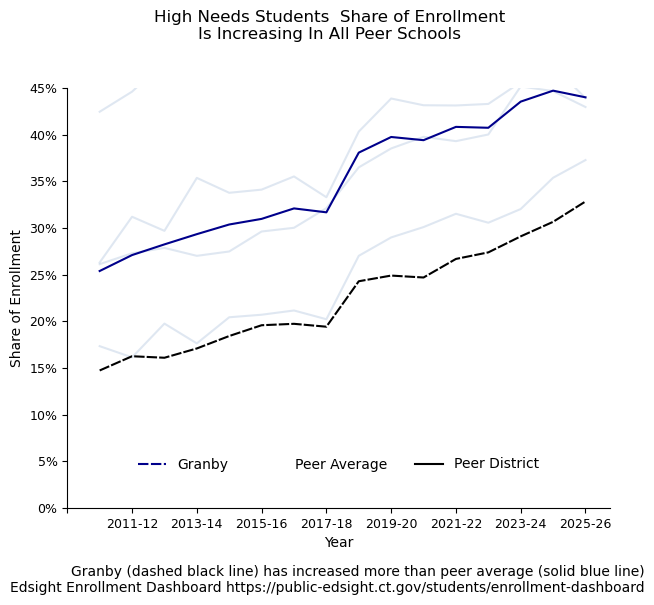

In [22]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['High Needs Students Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('High Needs Students  Share of Enrollment\nIs Increasing In All Peer Schools')

ax = sns.lineplot(data=tmpdf,
                y='High Needs Students Share of Enrollment', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)
labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Share of Enrollment')
ax.set_ylim(0, .45)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Edsight Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.show()

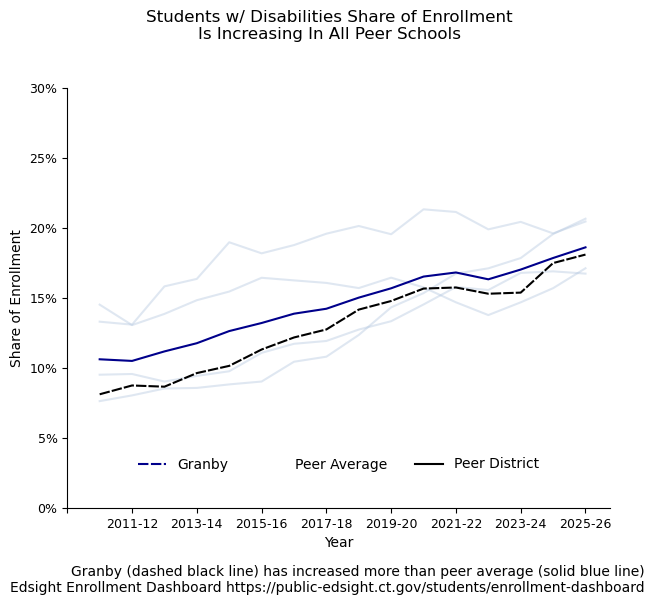

In [23]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Students w/ Disabilities Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Students w/ Disabilities Share of Enrollment\nIs Increasing In All Peer Schools')

ax = sns.lineplot(data=tmpdf,
                y='Students w/ Disabilities Share of Enrollment', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
ax.tick_params(axis='both', labelsize=9)

ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Share of Enrollment')
ax.set_ylim(0, .3)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Edsight Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

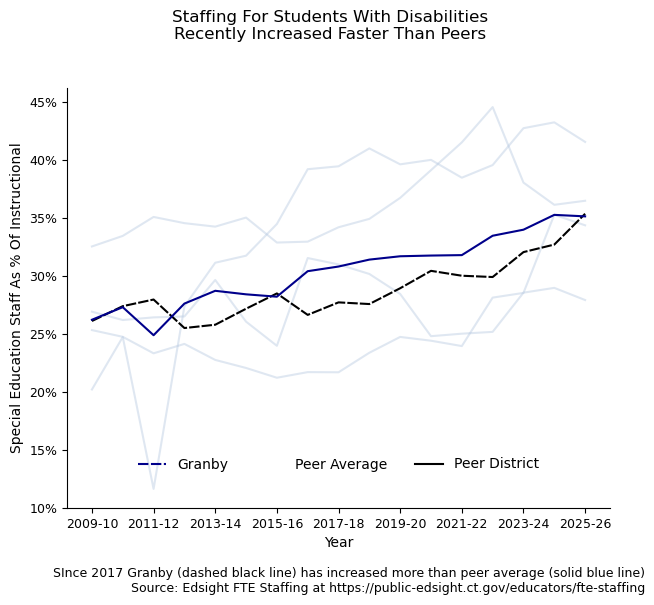

In [24]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Special Ed Share of Instructional'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Staffing For Students With Disabilities\nRecently Increased Faster Than Peers')

ax = sns.lineplot(data=tmpdf,
                y='Special Ed Share of Instructional', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
#labels[0].set_visible(False)
ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff As % Of Instructional')
#ax.set_ylim(0, .3)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "SInce 2017 Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.show()

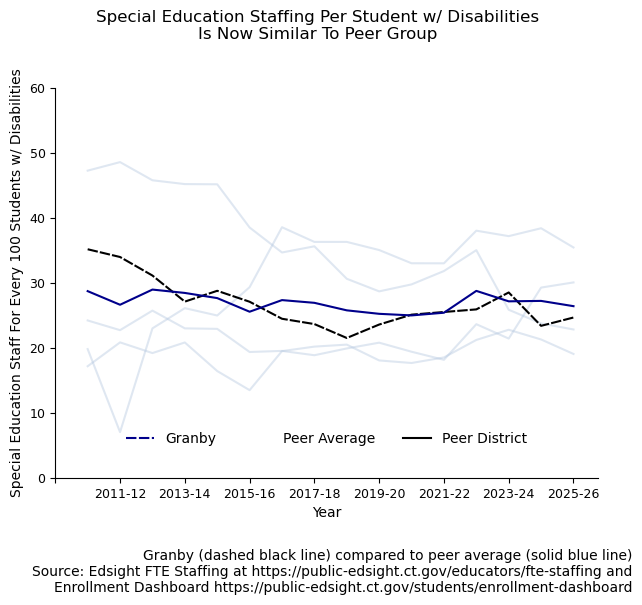

In [25]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['SpecialEd Per 100 Student w/ Disabilities'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Special Education Staffing Per Student w/ Disabilities\nIs Now Similar To Peer Group')

ax = sns.lineplot(data=tmpdf,
                y='SpecialEd Per 100 Student w/ Disabilities', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff For Every 100 Students w/ Disabilities')
ax.set_ylim(0, 60)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.2)

line1 = "Granby (dashed black line) compared to peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing and\n"
line3 = "Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 + line3 , fontsize=10, ha='right')

plt.show()

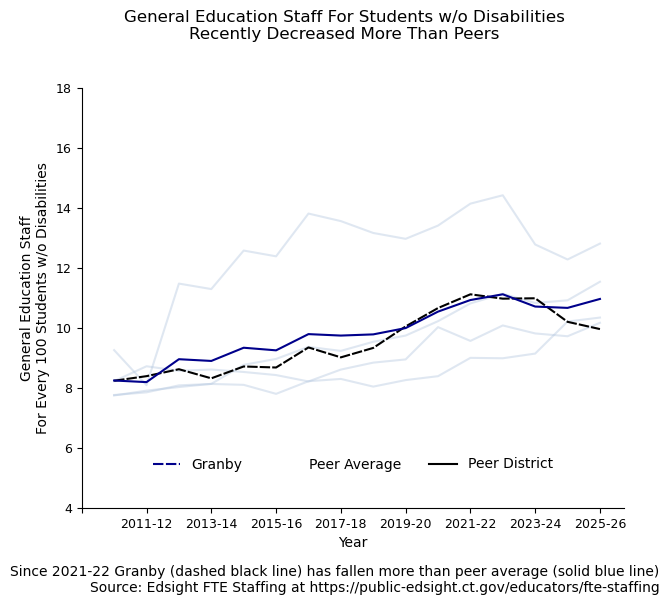

In [26]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Educational Per 100 Student w/o Disabilities'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}



fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('General Education Staff For Students w/o Disabilities\nRecently Decreased More Than Peers')

ax = sns.lineplot(data=tmpdf,
                y='Educational Per 100 Student w/o Disabilities', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('General Education Staff\nFor Every 100 Students w/o Disabilities')
ax.set_ylim(4, 18)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Since 2021-22 Granby (dashed black line) has fallen more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.show()

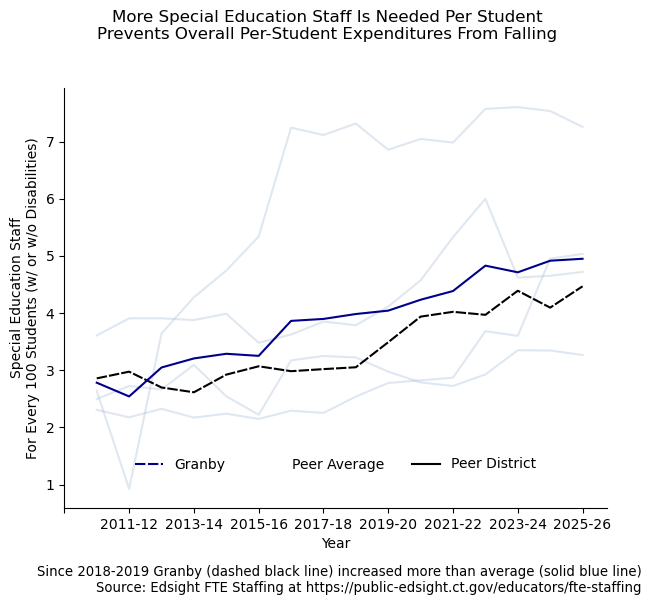

In [27]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['SpecialEd Per 100 Student'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('More Special Education Staff Is Needed Per Student\nPrevents Overall Per-Student Expenditures From Falling')

ax = sns.lineplot(data=tmpdf,
                y='SpecialEd Per 100 Student', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff\nFor Every 100 Students (w/ or w/o Disabilities)')
#ax.set_ylim(0, 60)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Since 2018-2019 Granby (dashed black line) increased more than average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9.5, ha='right')

plt.show()

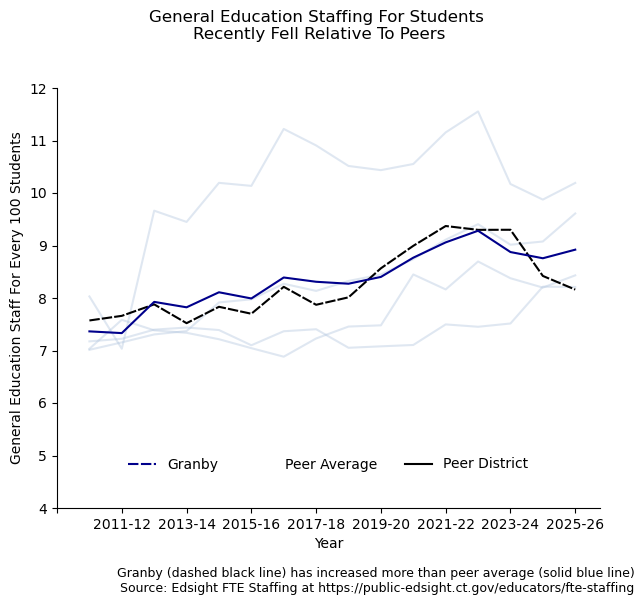

In [28]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Educational Per 100 Student'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}



fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('General Education Staffing For Students \nRecently Fell Relative To Peers')

ax = sns.lineplot(data=tmpdf,
                y='Educational Per 100 Student', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('General Education Staff For Every 100 Students')
ax.set_ylim(4, 12)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.show()

## Staff Proportions

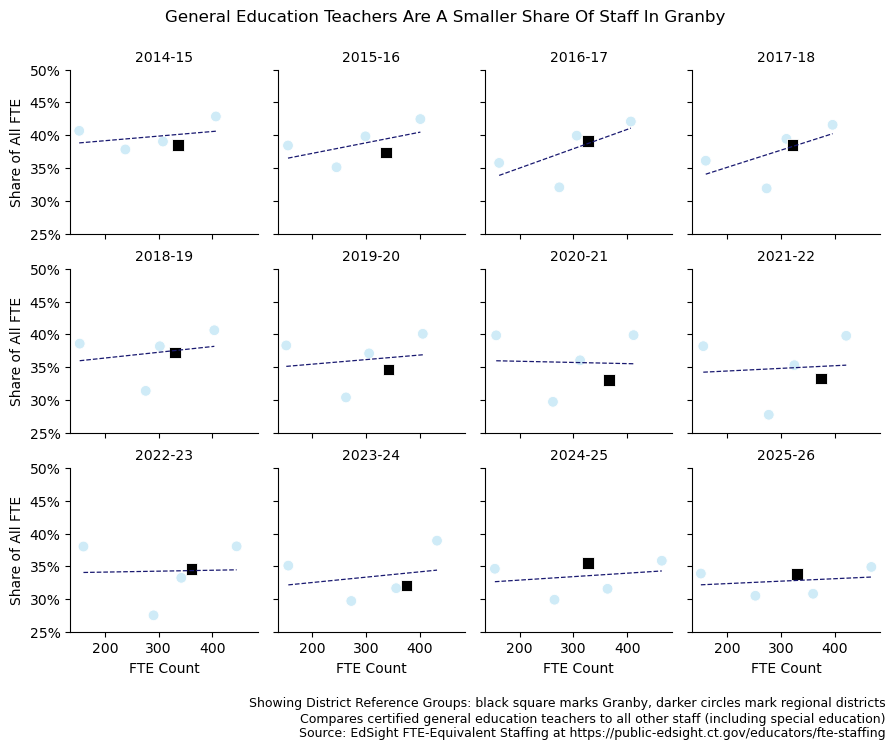

In [29]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               y='Teachers Share Of FTE', x='FTE Count',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('General Education Teachers Are A Smaller Share Of Staff In Granby')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='Teachers Share Of FTE', scatter=False, ci=None,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(.25,.5))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.set_ylabel('Share of All FTE')

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Compares certified general education teachers to all other staff (including special education)\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.show()

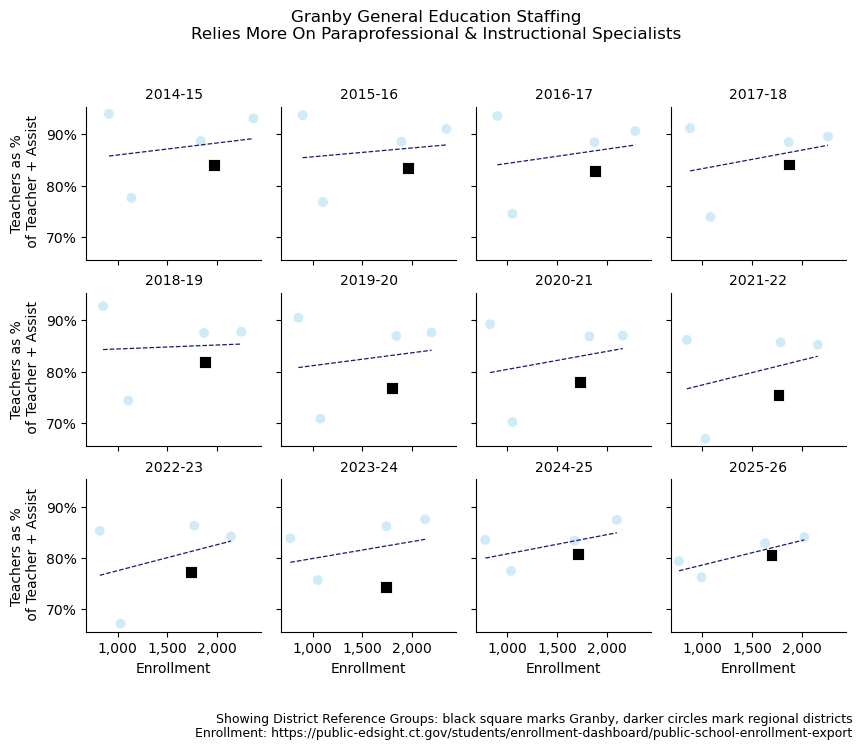

In [30]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Teachers Share of General Ed', 
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.figure.suptitle('Granby General Education Staffing\nRelies More On Paraprofessional & Instructional Specialists')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot,x='Enrollment', y='Teachers Share of General Ed', scatter=False, ci=None,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


g.set_ylabels(label='Teachers as %\n of Teacher + Assist')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Enrollment: https://public-edsight.ct.gov/students/enrollment-dashboard/public-school-enrollment-export"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)


plt.show()

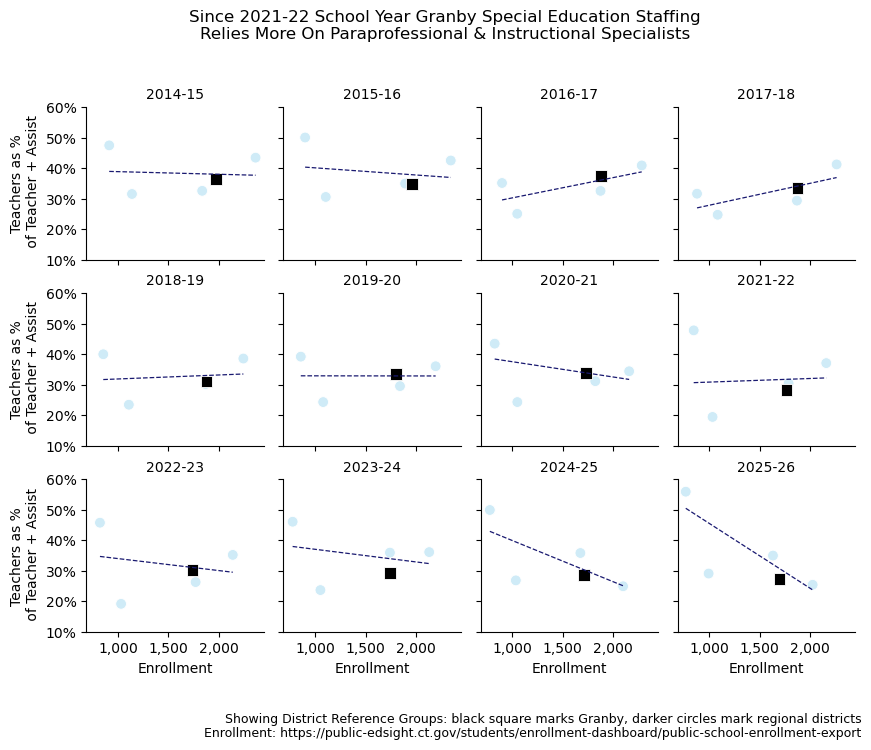

In [31]:

# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Teachers Share of Special Ed', 
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.figure.suptitle('Since 2021-22 School Year Granby Special Education Staffing\nRelies More On Paraprofessional & Instructional Specialists')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot,x='Enrollment', y='Teachers Share of Special Ed',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


g.set_ylabels(label='Teachers as %\n of Teacher + Assist')
for ax in g.axes.flat:
    ax.set_ylim(.1, .6)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Enrollment: https://public-edsight.ct.gov/students/enrollment-dashboard/public-school-enrollment-export"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)


plt.show()

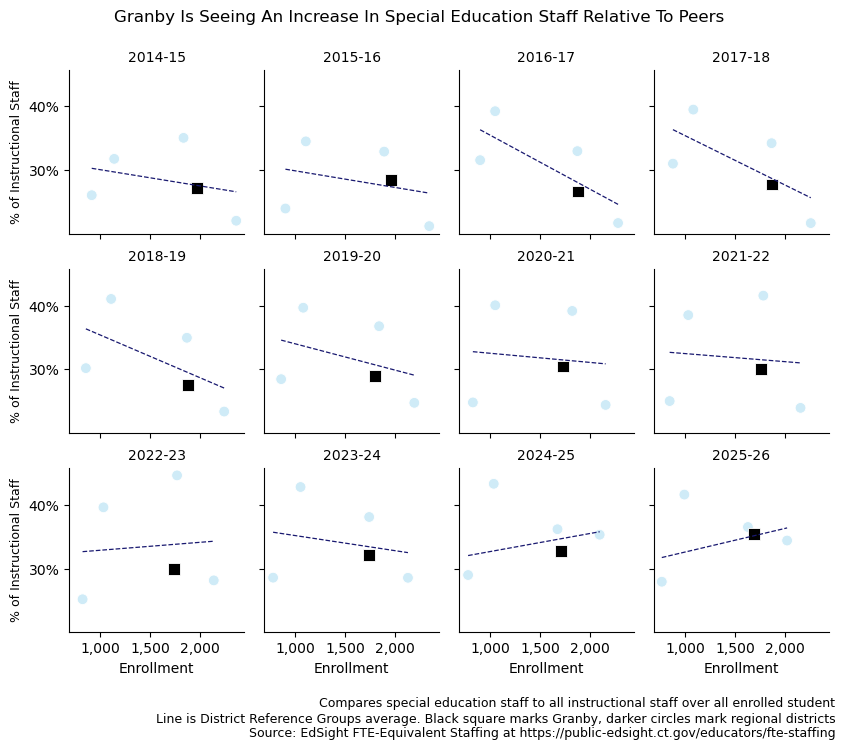

In [32]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
                x='Enrollment', y='Special Ed Share of Instructional',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Granby Is Seeing An Increase In Special Education Staff Relative To Peers')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Special Ed Share of Instructional',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels("% of Instructional Staff", fontsize=9)
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(comma)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Line is District Reference Groups average. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares special education staff to all instructional staff over all enrolled student\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_share_of_staff.png", dpi=200, metadata=png_metadata)

plt.show()

#### Administrators

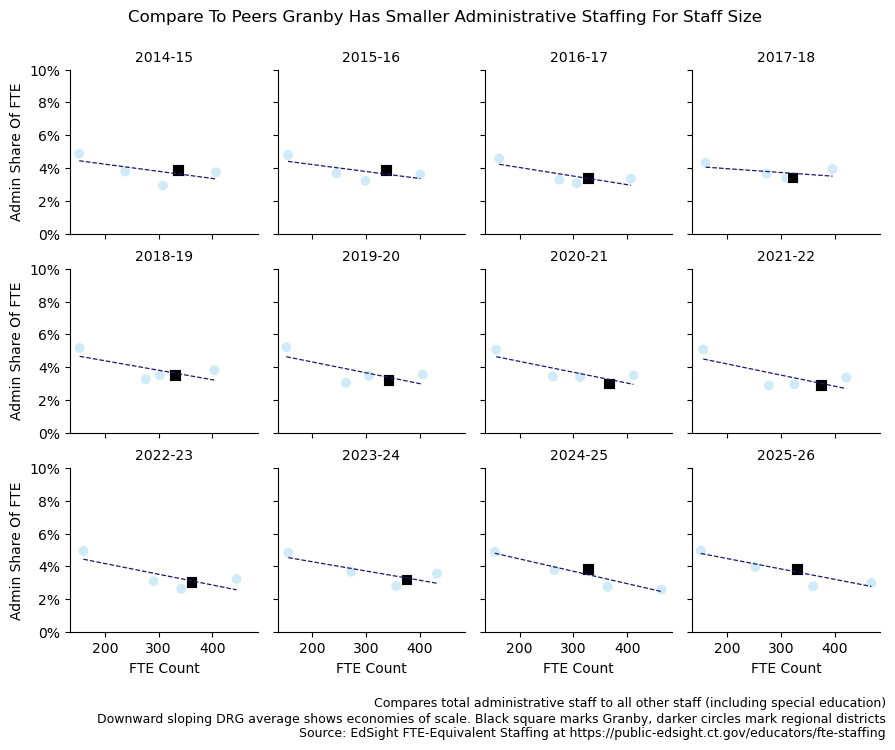

In [33]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='FTE Count', y='Admin Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Compare To Peers Granby Has Smaller Administrative Staffing For Staff Size')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='Admin Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(0,.1))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Downward sloping DRG average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares total administrative staff to all other staff (including special education)\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.show()

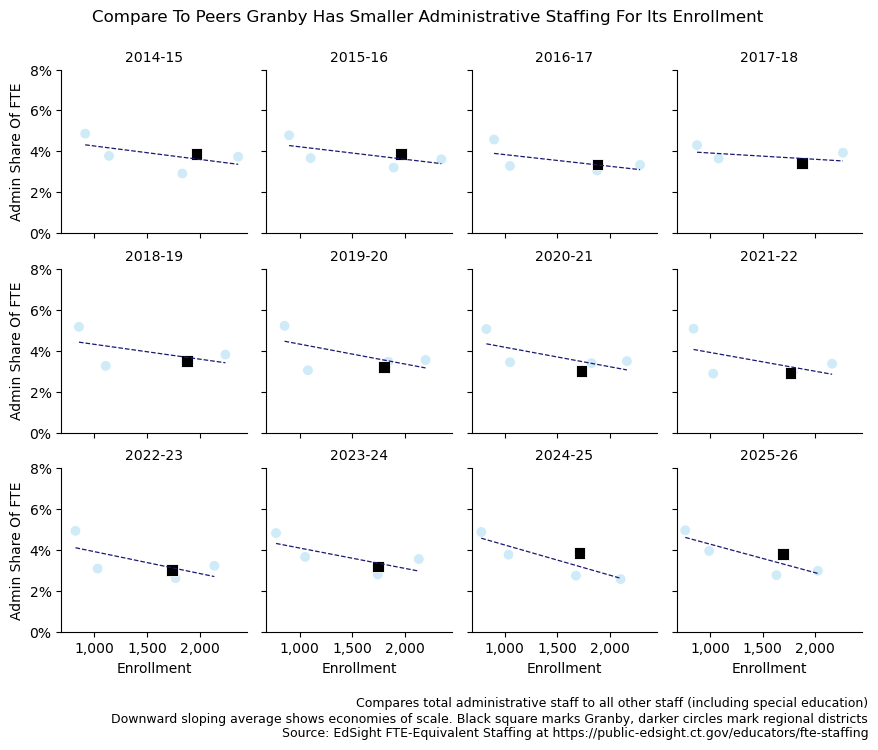

In [34]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Admin Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Compare To Peers Granby Has Smaller Administrative Staffing For Its Enrollment')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Admin Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(0,.08))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares total administrative staff to all other staff (including special education)\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.show()

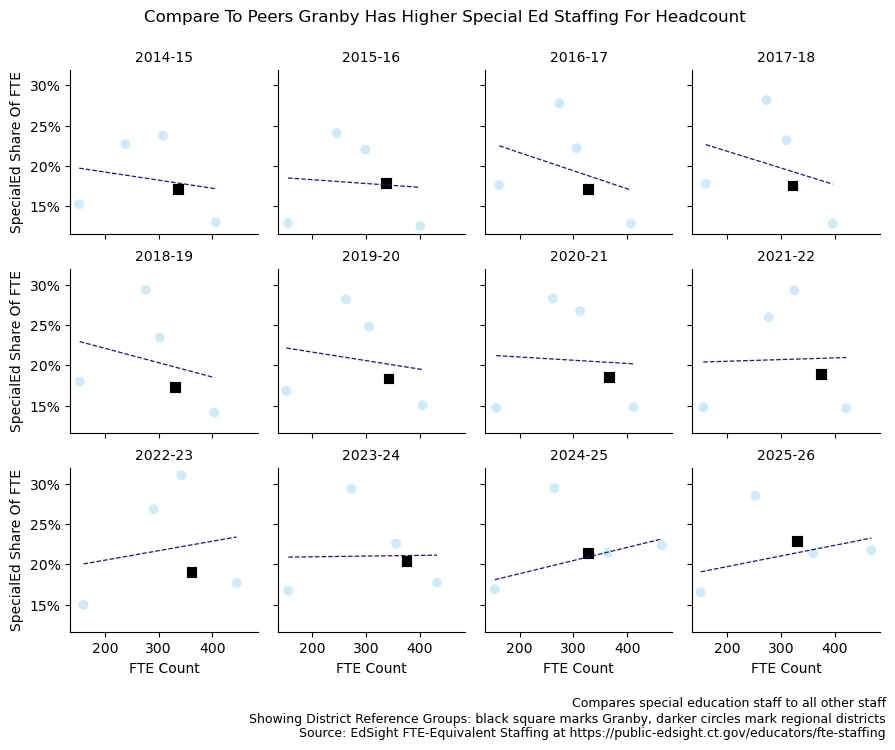

In [35]:

# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='FTE Count', y='SpecialEd Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Compare To Peers Granby Has Higher Special Ed Staffing For Headcount')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='SpecialEd Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares special education staff to all other staff\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.show()

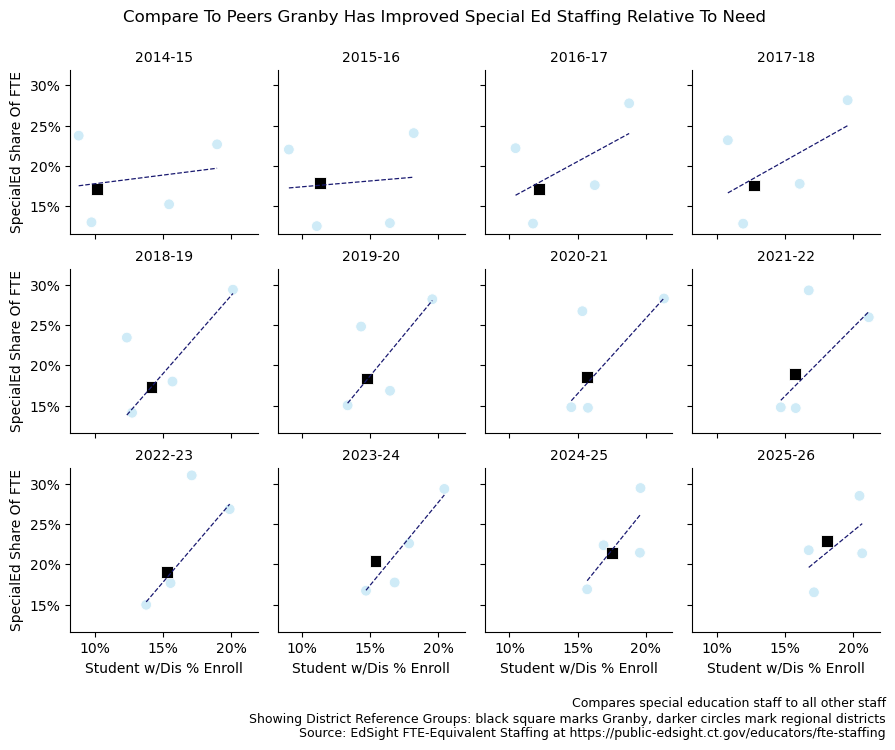

In [36]:

# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Students w/ Disabilities Share of Enrollment', y='SpecialEd Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Compare To Peers Granby Has Improved Special Ed Staffing Relative To Need')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, 
                x='Students w/ Disabilities Share of Enrollment', y='SpecialEd Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))
g.set(xlabel="Student w/Dis % Enroll")

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perci_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares special education staff to all other staff\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.show()

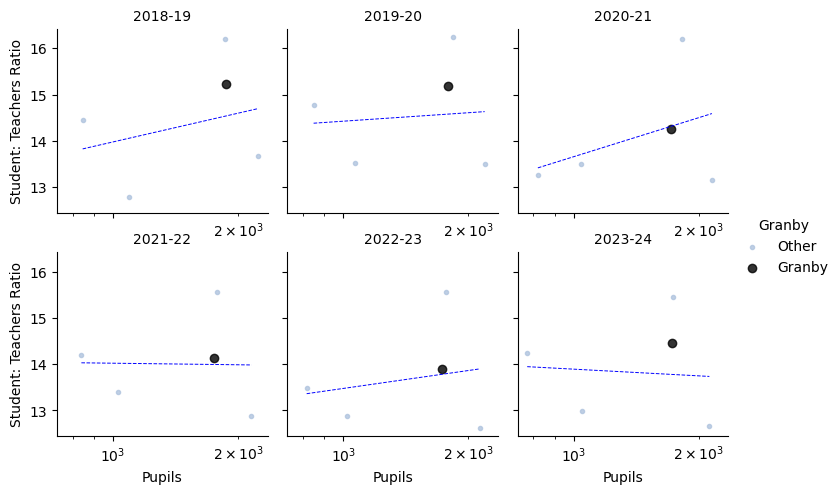

In [37]:
g = sns.lmplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
               y='Student: Teachers Ratio', x='Pupils',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=True, ci=None,
               markers=['.', 'o'], palette=['lightsteelblue', 'black'],
               line_kws={'ls': '--', 'color': 'blue', 'lw': .7})
g.set(xscale="log")
g.set_titles("{col_name}")
#style='Granby', size='Granby', alpha=.7, height=3, sizes=[9, 27], markers=['o', 'o'], palette=['orange', 'blue']

## Retention Data
It might be useful to look at the different types of exits: how many are still teaching and how many are not. That could be a way of marking retirement.

One thing here - the staff reduction may be intentional.

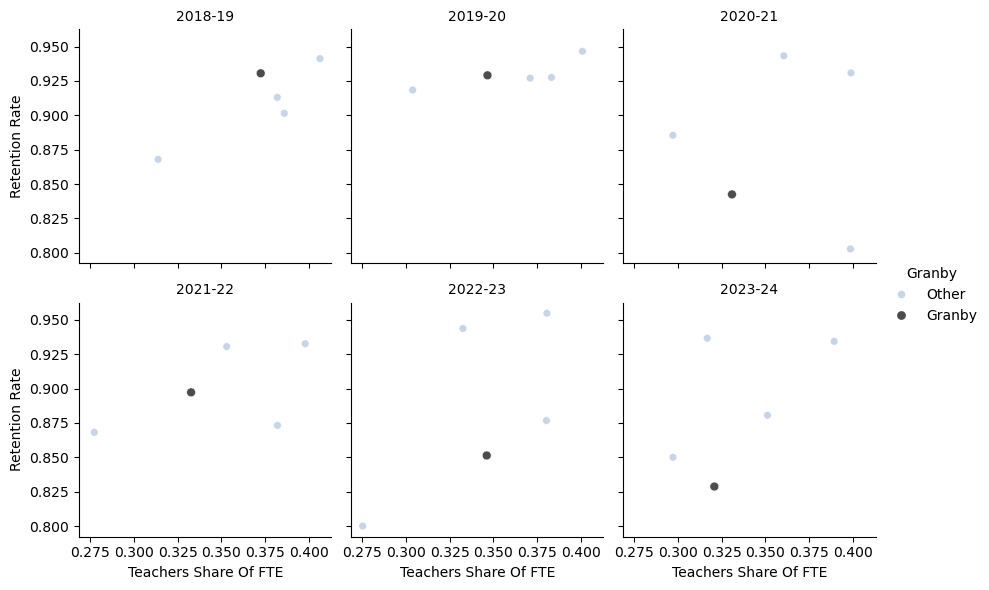

In [38]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Teachers Share Of FTE', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")
plt.show()

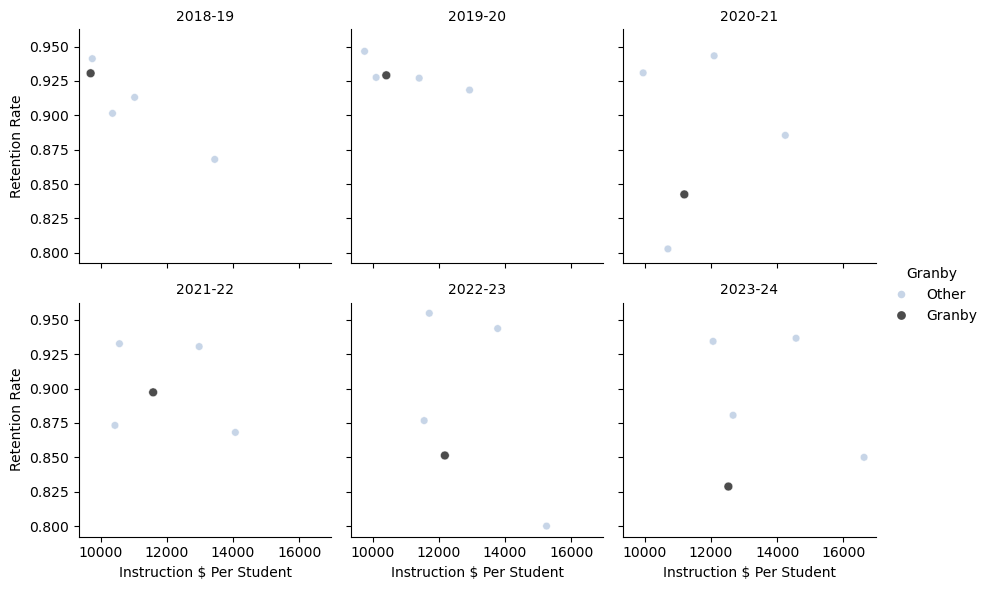

In [39]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Instruction $ Per Student', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")

## Expenditures
### Relative To Enrollment

In [40]:
peer_expenditures['Function'].value_counts()

Function
Instruction                                       65
Operation and maintenance of plant                65
Student transportation services                   65
Support services - general administration         65
Support services - instruction                    65
Support services - school based administration    65
Support services - students                       65
Central and other support services                40
Total                                             40
Administration and Support Services               25
Name: count, dtype: int64

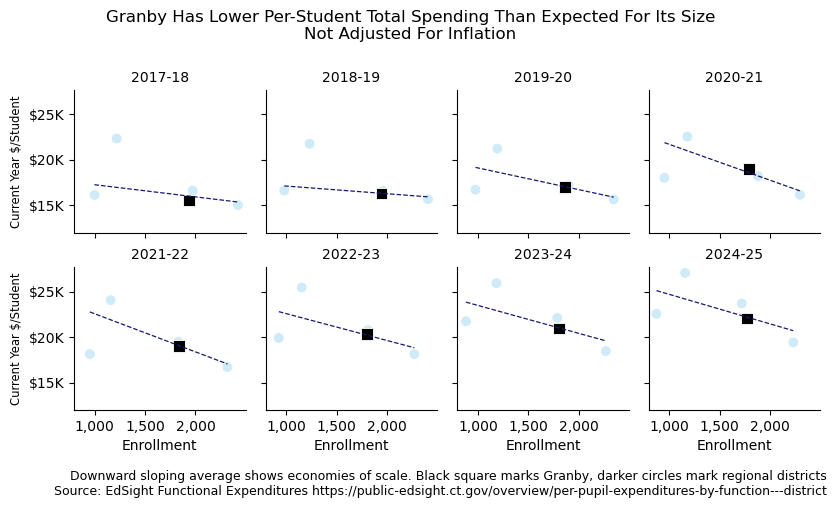

In [41]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])
                            & (peer_expenditures['Function'] == 'Total')],
               x='Pupils', y='PPE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Granby Has Lower Per-Student Total Spending Than Expected For Its Size\nNot Adjusted For Inflation')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupils', y='PPE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_xlabels("Enrollment")
for ax in g.axes.flat:
    ax.set_ylim(bottom=12000)
    ax.set_ylabel('Current Year $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.82, bottom=0.18)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/spend_v_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

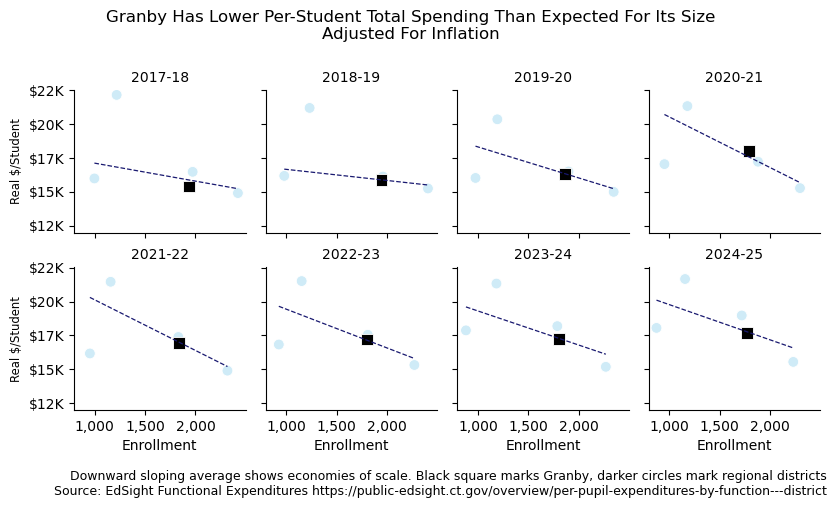

In [42]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])
                            & (peer_expenditures['Function'] == 'Total')],
               x='Pupils', y='Real PPE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Granby Has Lower Per-Student Total Spending Than Expected For Its Size\nAdjusted For Inflation')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupils', y='Real PPE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_xlabels("Enrollment")
for ax in g.axes.flat:
    ax.set_ylim(bottom=12000)
    ax.set_ylabel('Real $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

# for instructional $ plot
_bot, _top = g.axes.flat[0].get_ylim()
_range = _top - _bot

plt.subplots_adjust(top=.82, bottom=0.18)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/spend_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

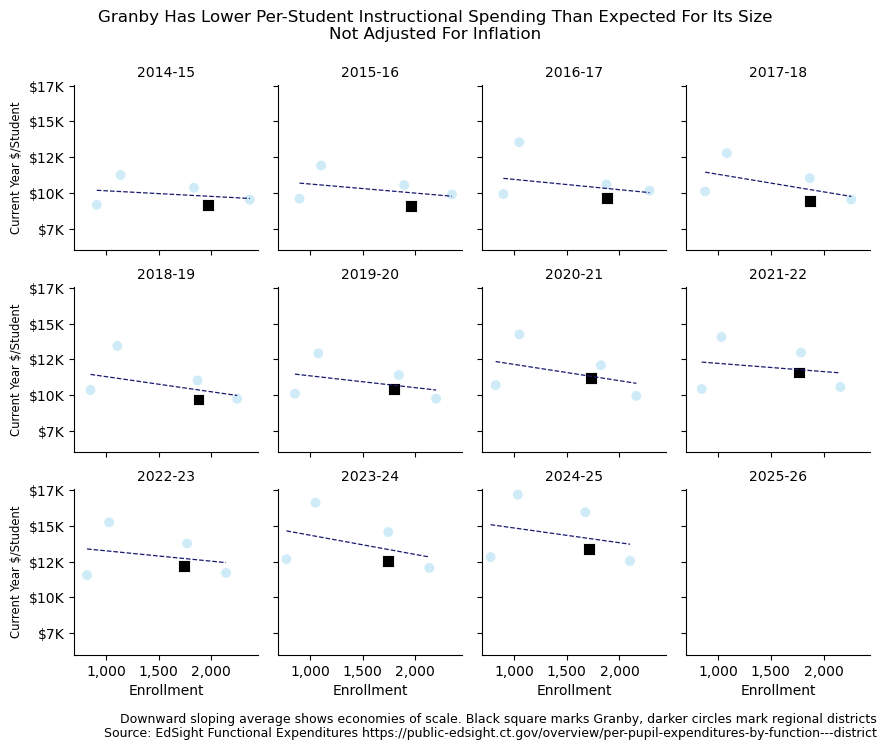

In [43]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Instruction $ Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Granby Has Lower Per-Student Instructional Spending Than Expected For Its Size\nNot Adjusted For Inflation')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Instruction $ Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


for ax in g.axes.flat:
    ax.set_ylim(bottom=6000)
    ax.set_ylabel('Current Year $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.88, bottom=0.12)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/instructional_v_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

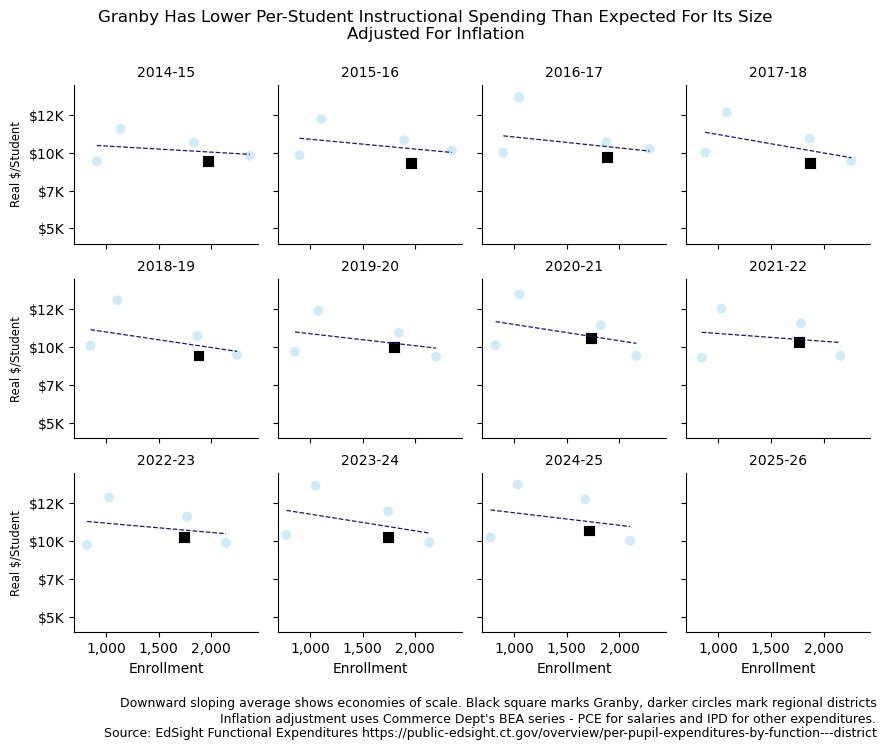

In [44]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Real Instruction $ Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle('Granby Has Lower Per-Student Instructional Spending Than Expected For Its Size\nAdjusted For Inflation')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Real Instruction $ Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

for ax in g.axes.flat:
    ax.set_ylim(bottom=4000, top=4000 + _range)
    ax.set_ylabel('Real $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.88, bottom=0.15)
line1 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line2 = "Inflation adjustment uses Commerce Dept's BEA series - PCE for salaries and IPD for other expenditures.\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/instructional_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

## Accountability Index

### NO COVID YEARS!

Granby does not have Progress Toward English Proficiency (ESL)

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

## Reshape Data
Easier way to work with hues

In [45]:
# reshape accountability wide-to-long for seaborn
peer_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=values,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

high_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=high_need,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

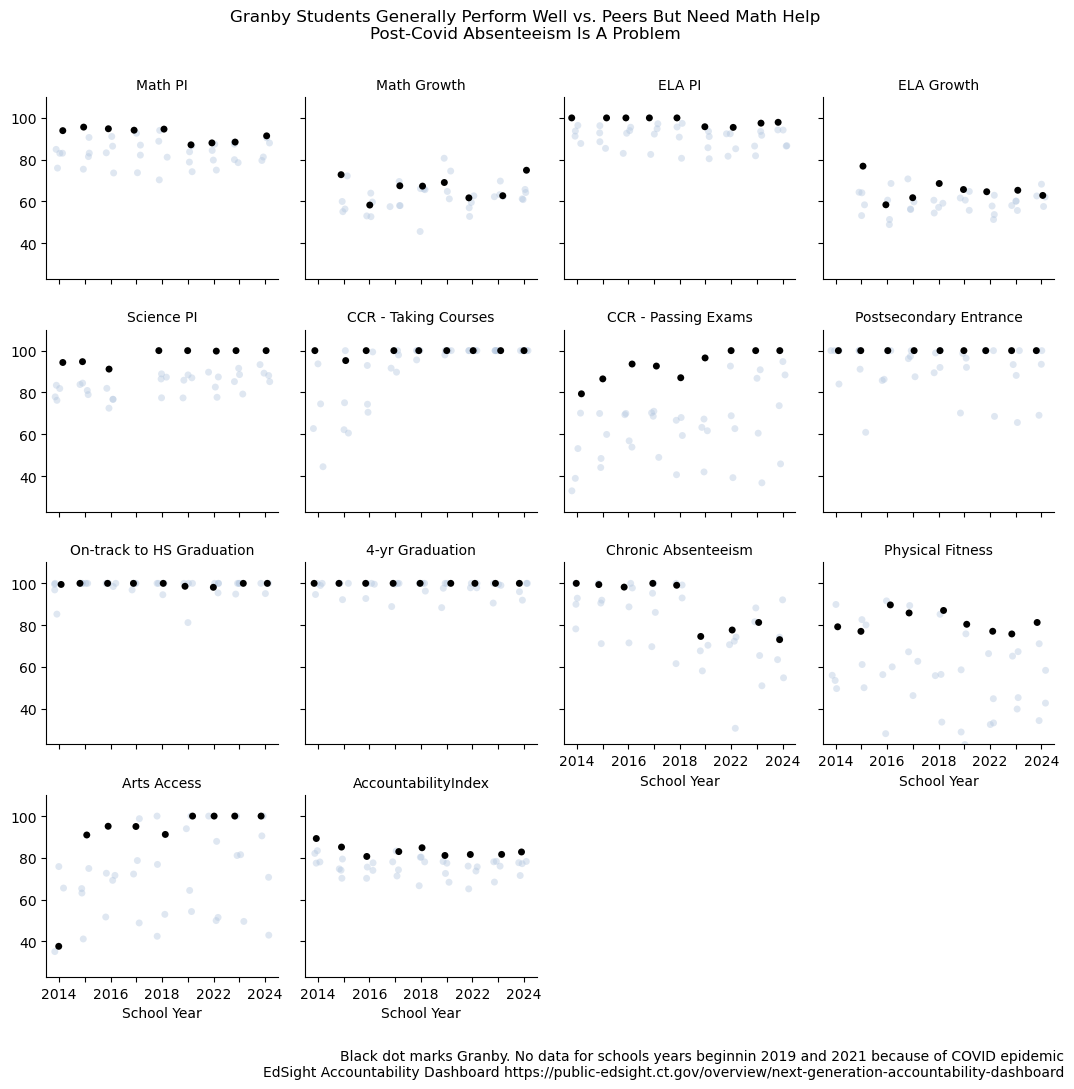

In [46]:
g = sns.catplot(data=peer_long,
                y='value', x='School Year', hue='District', kind='strip', jitter=.2,
                col='metric', col_wrap=4, legend=False,
                height=2.75, palette=school_cols)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(23, 110)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle("Granby Students Generally Perform Well vs. Peers But Need Math Help\nPost-Covid Absenteeism Is A Problem")
plt.subplots_adjust(top=.9, bottom=0.1)
line1 = "Black dot marks Granby. No data for schools years beginnin 2019 and 2021 because of COVID epidemic\n"
line2 = "EdSight Accountability Dashboard https://public-edsight.ct.gov/overview/next-generation-accountability-dashboard"
g.fig.text(.99, .01, line1 + line2 , ha='right', fontsize=10)

plt.savefig(f"./charts/accountability/{PEERVAR}/facetgrid_general.png", dpi=200, metadata=png_metadata)

plt.show()

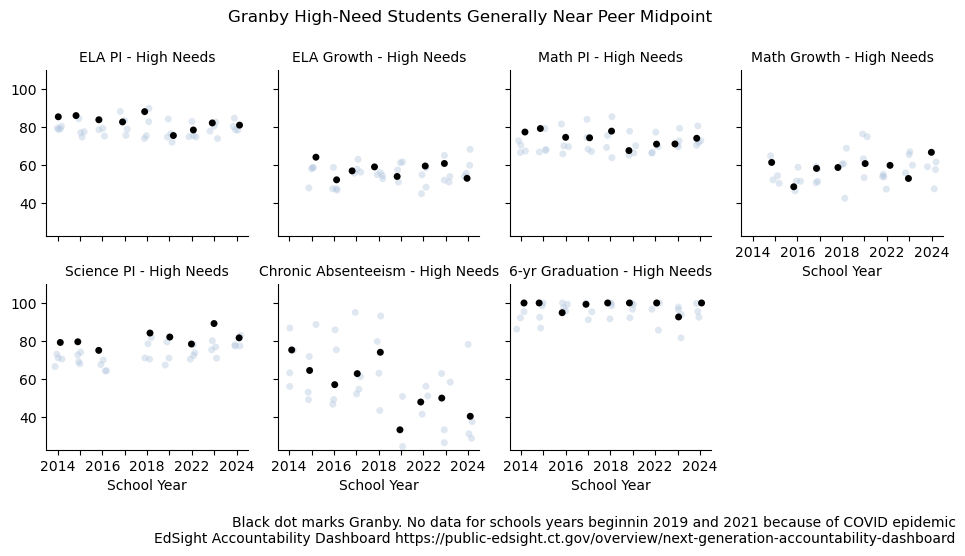

In [47]:
g = sns.catplot(data=high_long,
                y='value', x='School Year', hue='District', kind='strip', jitter=.2,
                col='metric', col_wrap=4, legend=False,
                height=2.75, aspect=.9, palette=school_cols)

g.set_titles("{col_name}")
g.set_ylabels(label='')

for ax in g.axes.flat:
    ax.set_ylim(23, 110)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        
g.fig.suptitle("Granby High-Need Students Generally Near Peer Midpoint")
plt.subplots_adjust(top=.87, bottom=0.18)
line1 = "Black dot marks Granby. No data for schools years beginnin 2019 and 2021 because of COVID epidemic\n"
line2 = "EdSight Accountability Dashboard https://public-edsight.ct.gov/overview/next-generation-accountability-dashboard"
g.fig.text(.99, .01, line1 + line2 , ha='right', fontsize=10)


plt.savefig(f"./charts/accountability/{PEERVAR}/facetgrid_highneed.png", dpi=200, metadata=png_metadata)


plt.show()

### Performance per Dollar

In [48]:
peer_instruction.columns

Index(['index', 'District', 'Function', 'Expenditures', 'Pupils',
       'Pupil Basis', 'PPE', 'Year', 'Town', 'Type',
       ...
       'Special Ed Share of Instructional',
       'High Needs Students Share of Enrollment',
       'Students w/ Disabilities Share of Enrollment',
       'SpecialEd Per 100 Student w/ Disabilities',
       'Educational Per 100 Student w/o Disabilities',
       'Teachers Per 100 Student w/o Disabilities',
       'Students w/ Disabilities: Teacher Ratio',
       'Students w/o Disabilities: Teacher Ratio',
       'Students w/o Disabilities: Educational Ratio',
       'SpecialEd Share Of Ed'],
      dtype='object', length=167)

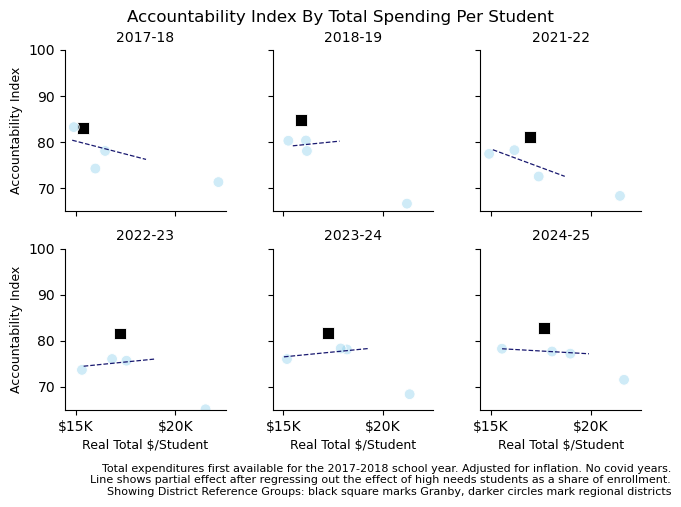

In [49]:

# limit to 12 years
g = sns.relplot(data=peer_combined[~(peer_combined['School Year'].isin(('2012', '2013', '2019', '2020')))],
                x='Real PPE', y='AccountabilityIndex',
               col='Year', col_wrap=3,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle("Accountability Index By Total Spending Per Student")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real PPE', y='AccountabilityIndex',
                x_partial='High Needs Students Share of Enrollment',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

g.set_ylabels("Accountability Index", fontsize=9)
g.set_xlabels("Real Total $/Student", fontsize=9)
for ax in g.axes.flat:
    ax.set_ylim(65,100)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    ax.yaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.9, bottom=0.18)

line1 = "Total expenditures first available for the 2017-2018 school year. Adjusted for inflation. No covid years.\n"
line2 = "Line shows partial effect after regressing out the effect of high needs students as a share of enrollment.\n"
line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts"

g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=8)

plt.show()

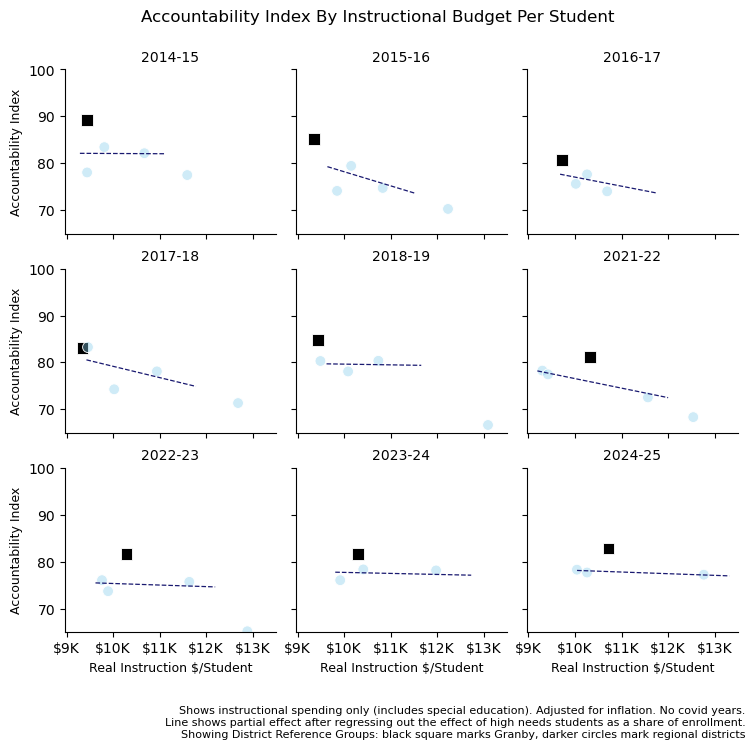

In [50]:
# limit to 12 years
g = sns.relplot(data=peer_instruction[~(peer_instruction['School Year'].isin(('2012', '2013', '2019', '2020')))],
                x='Real PPE', y='AccountabilityIndex',
               col='Year', col_wrap=3,
               height=2.5, aspect=1, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle("Accountability Index By Instructional Budget Per Student")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real PPE', y='AccountabilityIndex',
                x_partial='High Needs Students Share of Enrollment',
                scatter=False, ci=None, robust=True, 
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels("Accountability Index", fontsize=9)
g.set_xlabels("Real Instruction $/Student", fontsize=9)
for ax in g.axes.flat:
    ax.set_ylim(65,100)
    ax.set_xlim(right=13500)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    ax.yaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows instructional spending only (includes special education). Adjusted for inflation. No covid years.\n"
line2 = "Line shows partial effect after regressing out the effect of high needs students as a share of enrollment.\n"
line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts"

g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=8)

plt.savefig(f"./charts/staffing/{PEERVAR}/accountability_by_ppe.png", dpi=200, metadata=png_metadata)

plt.show()

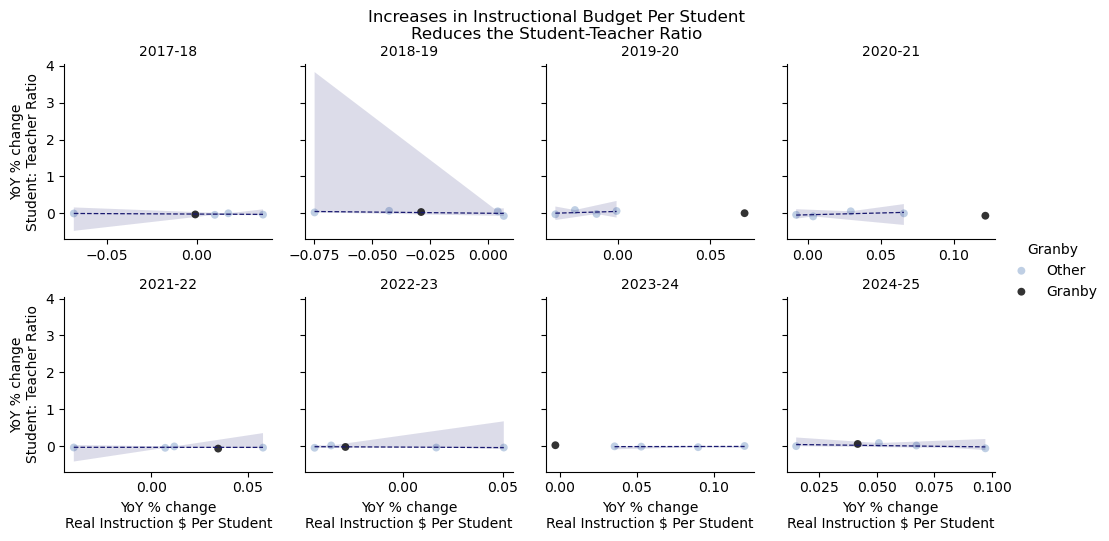

In [51]:
g = sns.lmplot(data=changes[(~changes['District'].isin(('Regional School District 06',
                                                       )))
                            & (changes['Year'] > '2016-17')],
               y='Student: Teachers Ratio', x='Real Instruction $ Per Student',
               col='Year', col_wrap=4, hue='Granby', height=2.5, 
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.fig.suptitle("Increases in Instructional Budget Per Student\nReduces the Student-Teacher Ratio", y=1.04)
g.set_titles("{col_name}")
g.set_ylabels("YoY % change\nStudent: Teacher Ratio")
g.set_xlabels("YoY % change\nReal Instruction $ Per Student")
plt.show()

In [52]:
changes.columns

Index(['Pupils', 'PPE', 'Instruction $', 'Instruction $ Per Student',
       'Real Instruction $', 'Real PPE', 'Real Instruction $ Per Student',
       'Teachers', 'Educational', 'Student: Teachers Ratio',
       'AccountabilityIndex', 'District', 'Year', 'Town', 'Type', 'Granby'],
      dtype='object')

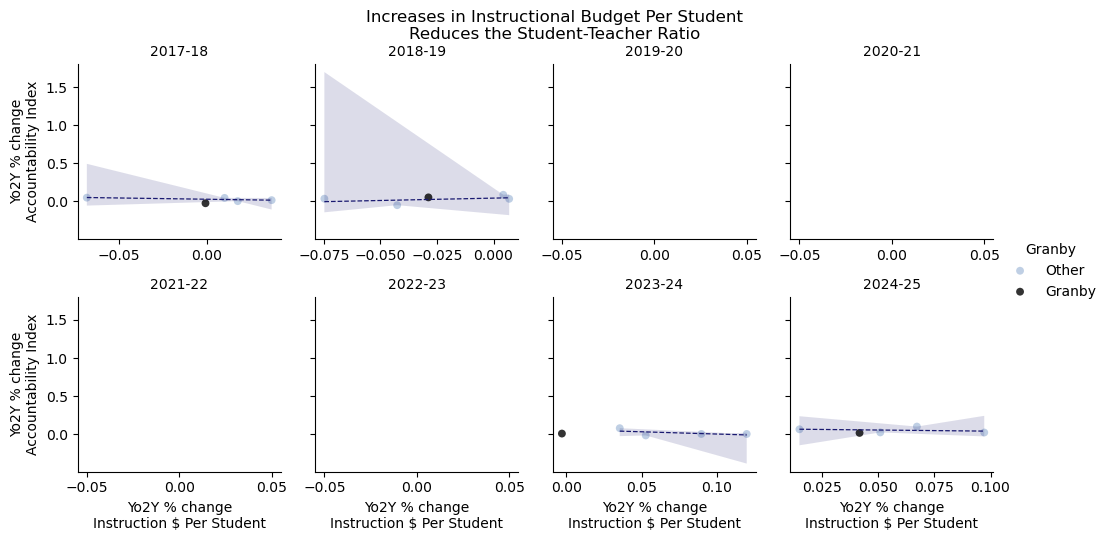

In [53]:
# No data 2019, 2020, which is numerator for 2 years and denominator for 2 years
g = sns.lmplot(data=changes[(~changes['District'].isin(('Regional School District 06',
                                                       )))
                            & (changes['Year'] > '2016-17')],
               y='AccountabilityIndex', x='Real Instruction $ Per Student',
               col='Year', col_wrap=4, hue='Granby', height=2.5, 
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.fig.suptitle("Increases in Instructional Budget Per Student\nReduces the Student-Teacher Ratio", y=1.04)
g.set_titles("{col_name}")
g.set_ylabels("Yo2Y % change\nAccountability Index")
g.set_xlabels("Yo2Y % change\nInstruction $ Per Student")
plt.show()

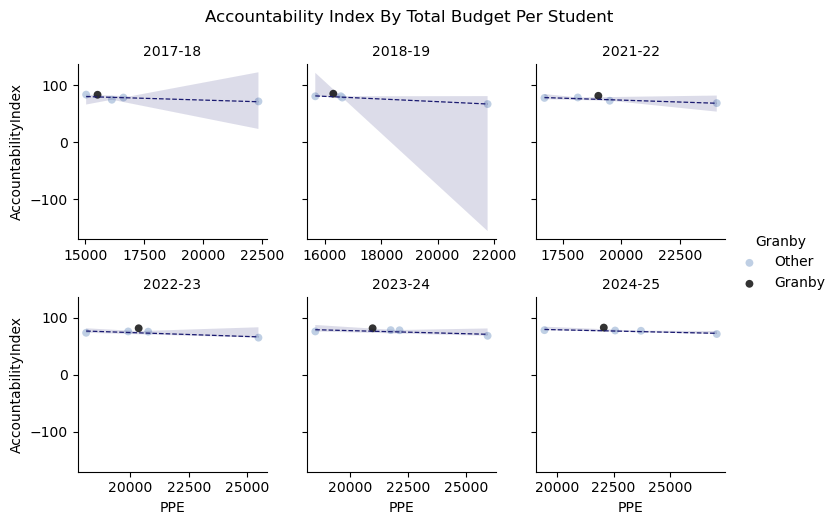

In [54]:
g = sns.lmplot(data=peer_combined[(~peer_combined['School Year'].isin(('2019','2020'))) & (peer_combined['District'] != 'Regional School District 12')],
               y='AccountabilityIndex', x='PPE', 
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.fig.suptitle("Accountability Index By Total Budget Per Student", y=1.04)
g.set_titles("{col_name}")
plt.show()

In [55]:
peer_combined[(peer_combined['School Year'] >= '2024') & (peer_combined['District'] != 'Regional School District 12')][['District', 'PPE']]

,District,PPE
35,East Hampton School District,23714.0
36,East Windsor School District,27076.0
37,Granby School District,22065.0
38,Thomaston School District,22567.0
39,Wolcott School District,19433.0


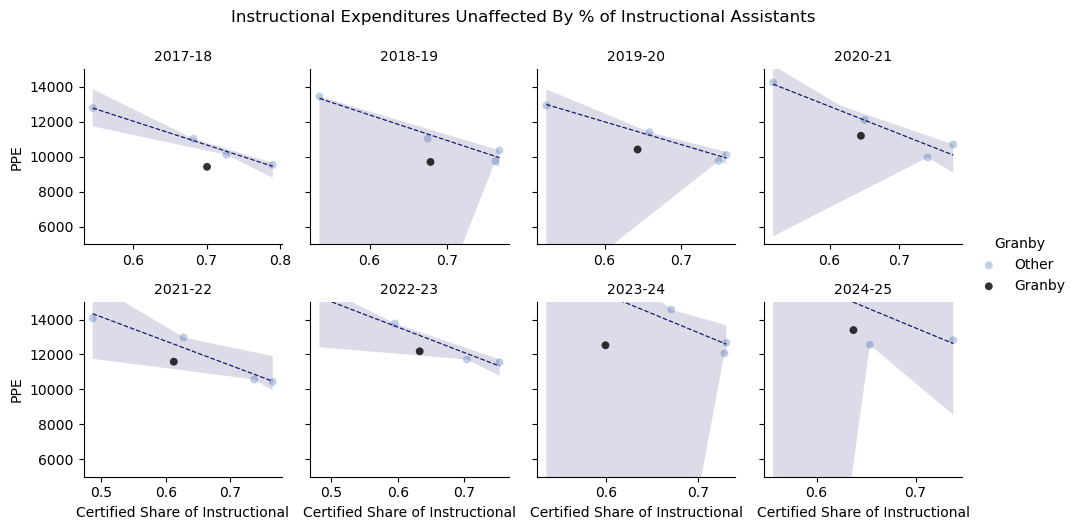

In [56]:
g = sns.lmplot(data=peer_instruction[peer_instruction['Year'] >= '2017'],
                y='PPE', x='Certified Share of Instructional', 
               col='Year', col_wrap=4, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'},
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.set_titles("{col_name}")

g.set(ylim=(5000, 15000))
g.figure.suptitle('Instructional Expenditures Unaffected By % of Instructional Assistants', y=1.05)
plt.show()
#style='Granby', size='Granby', alpha=.7, height=2.5, sizes=[9, 27],

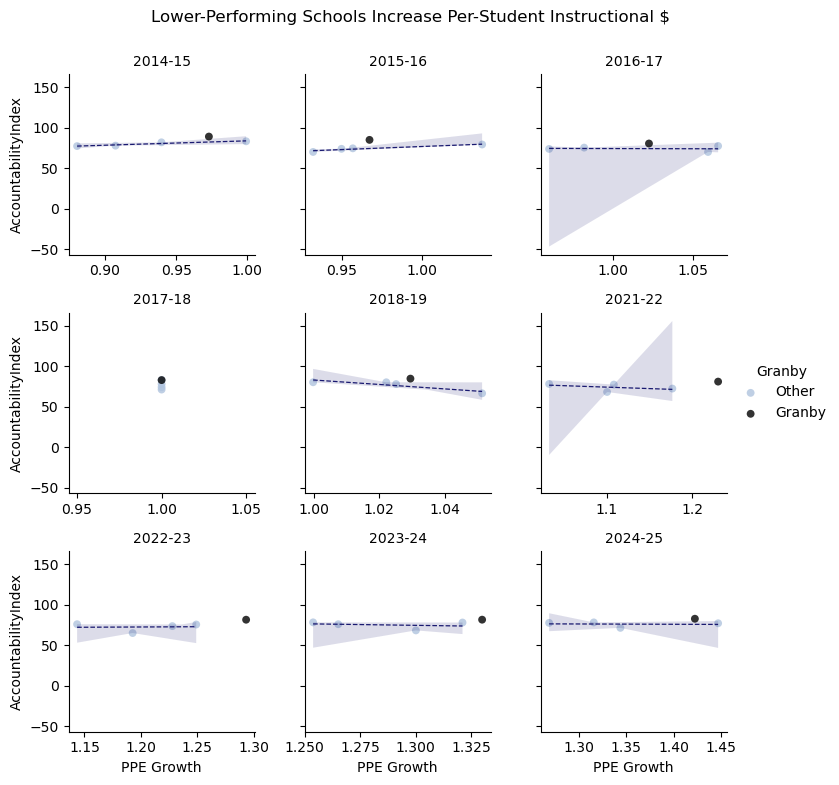

In [57]:
g = sns.lmplot(data=peer_instruction[(~peer_instruction['School Year'].isin(('2012', '2013', '2019','2020')))],
               y='AccountabilityIndex', x='PPE Growth',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.fig.suptitle("Lower-Performing Schools Increase Per-Student Instructional $", y=1.04)
g.set_titles("{col_name}")
plt.show()

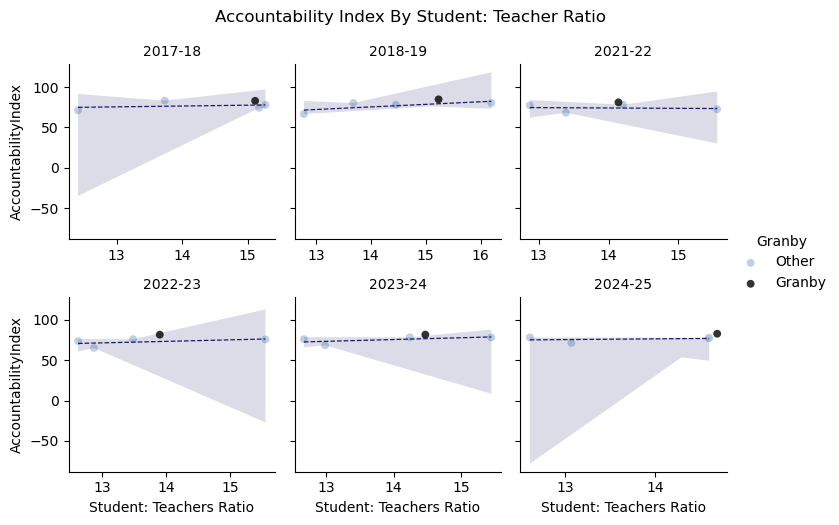

In [58]:
g = sns.lmplot(data=peer_combined[(~peer_combined['School Year'].isin(('2012', '2013', '2019','2020')))],
               y='AccountabilityIndex', x='Student: Teachers Ratio',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.fig.suptitle("Accountability Index By Student: Teacher Ratio", y=1.04)
g.set_titles("{col_name}")
plt.show()